André Domingues Teixeira - 24005334

In [1]:
import random
import time
import statistics
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# INSERTION SORT
# Pior caso: O(n²)
def insertion_sort(vetor):
    arr = vetor.copy()
    movimentos = 0

    for i in range(1, len(arr)):
        chave = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > chave:
            arr[j + 1] = arr[j]
            movimentos += 1
            j -= 1

        arr[j + 1] = chave
        movimentos += 1

    return movimentos


# MERGE SORT
# Pior caso: O(n log n)
def merge_sort(vetor):
    arr = vetor.copy()
    movimentos = 0

    def merge_sort_rec(lista):
        nonlocal movimentos

        if len(lista) <= 1:
            return lista

        meio = len(lista) // 2
        esquerda = merge_sort_rec(lista[:meio])
        direita = merge_sort_rec(lista[meio:])

        resultado = []
        i = 0
        j = 0

        while i < len(esquerda) and j < len(direita):
            if esquerda[i] <= direita[j]:
                resultado.append(esquerda[i])
                i += 1
            else:
                resultado.append(direita[j])
                j += 1

            movimentos += 1

        while i < len(esquerda):
            resultado.append(esquerda[i])
            i += 1
            movimentos += 1

        while j < len(direita):
            resultado.append(direita[j])
            j += 1
            movimentos += 1

        return resultado

    merge_sort_rec(arr)
    return movimentos


# QUICK SORT
# Pior caso: O(n²)
def quick_sort(vetor):
    arr = vetor.copy()
    trocas = 0

    def trocar(i, j):
        nonlocal trocas

        if i != j:
            arr[i], arr[j] = arr[j], arr[i]
            trocas += 1

    def particionar(inicio, fim):
        pivo = arr[fim]
        i = inicio - 1

        for j in range(inicio, fim):
            if arr[j] <= pivo:
                i += 1
                trocar(i, j)

        trocar(i + 1, fim)
        return i + 1

    def quick_sort_rec(inicio, fim):
        if inicio < fim:
            p = particionar(inicio, fim)
            quick_sort_rec(inicio, p - 1)
            quick_sort_rec(p + 1, fim)

    quick_sort_rec(0, len(arr) - 1)
    return trocas

In [3]:
def medir_tempo(funcao, vetor):
    inicio = time.perf_counter()
    movimentos = funcao(vetor)
    fim = time.perf_counter()

    tempo = fim - inicio
    return tempo, movimentos

In [4]:
algoritmos = {
    "Insertion Sort": {
        "funcao": insertion_sort,
        "complexidade": "O(n²)",
    },
    "Merge Sort": {
        "funcao": merge_sort,
        "complexidade": "O(n log n)",
    },
    "Quick Sort": {
        "funcao": quick_sort,
        "complexidade": "O(n²)",
    },
}

tamanhos = [1000, 10000, 100000]

resultados = []

random.seed(10)

for tamanho in tamanhos:
    vetor_original = [random.randint(1, 1000000) for _ in range(tamanho)]

    for nome, dados in algoritmos.items():
        funcao = dados["funcao"]
        tempos = []
        movimentos_registrados = []

        for execucao in range(1, 4):

            if nome == "Insertion Sort" and tamanho == 100000:
                tempos.append("N/C")
                movimentos_registrados.append("N/C")
                continue

            tempo, movimentos = medir_tempo(funcao, vetor_original)

            tempos.append(tempo)
            movimentos_registrados.append(movimentos)

        tempos_validos = [t for t in tempos if isinstance(t, float)]

        if len(tempos_validos) > 0:
            tempo_medio = statistics.mean(tempos_validos)
            desvio_padrao = statistics.stdev(tempos_validos)
        else:
            tempo_medio = "N/C"
            desvio_padrao = "N/C"

        movimentos_validos = [m for m in movimentos_registrados if isinstance(m, int)]

        if len(movimentos_validos) > 0:
            media_movimentos = round(statistics.mean(movimentos_validos))
        else:
            media_movimentos = "N/C"

        resultados.append({
            "Algoritmo": nome,
            "Complexidade (pior caso)": dados["complexidade"],
            "Tamanho": tamanho,
            "Tempo Execução 1": tempos[0],
            "Tempo Execução 2": tempos[1],
            "Tempo Execução 3": tempos[2],
            "Tempo Médio": tempo_medio,
            "Desvio Padrão": desvio_padrao,
            "Trocas/Movimentações": media_movimentos
        })

df = pd.DataFrame(resultados)

display(df)

,Algoritmo,Complexidade (pior caso),Tamanho,Tempo Execução 1,Tempo Execução 2,Tempo Execução 3,Tempo Médio,Desvio Padrão,Trocas/Movimentações
0,Insertion Sort,O(n²),1000,0.0394,0.0498,0.0388,0.042667,0.006185,249959
1,Merge Sort,O(n log n),1000,0.0027,0.0026,0.0025,0.0026,0.0001,9976
2,Quick Sort,O(n²),1000,0.0022,0.0023,0.0022,0.002233,0.000058,5890
3,Insertion Sort,O(n²),10000,4.3571,4.3993,4.4304,4.3956,0.03679,25065644
4,Merge Sort,O(n log n),10000,0.0352,0.0344,0.0359,0.035167,0.000751,133616
5,Quick Sort,O(n²),10000,0.0291,0.0294,0.0296,0.029367,0.000252,69877
6,Insertion Sort,O(n²),100000,N/C,N/C,N/C,N/C,N/C,N/C
7,Merge Sort,O(n log n),100000,0.4587,0.4609,0.4611,0.460233,0.001332,1668928
8,Quick Sort,O(n²),100000,0.4403,0.4148,0.3891,0.414733,0.0256,906461


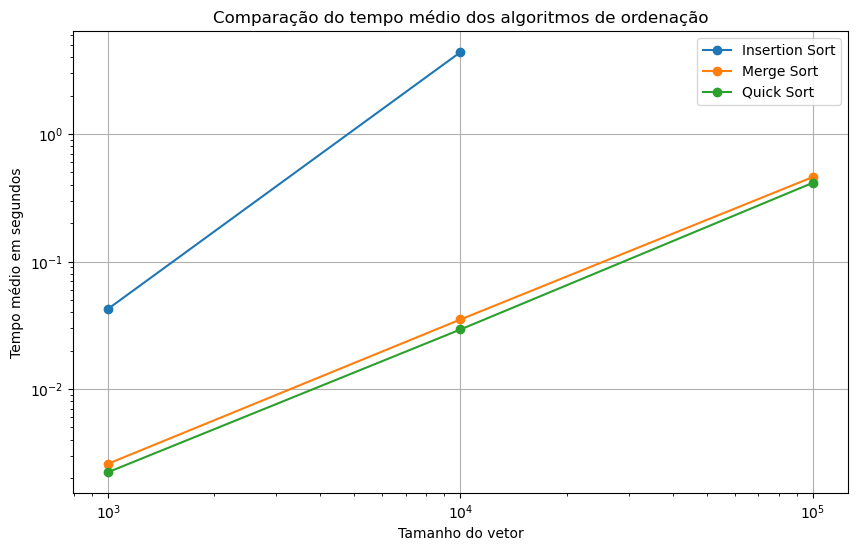

In [5]:
df_grafico = df[df["Tempo Médio"] != "N/C"].copy()
df_grafico["Tempo Médio"] = df_grafico["Tempo Médio"].astype(float)

plt.figure(figsize=(10, 6))

for algoritmo in df_grafico["Algoritmo"].unique():
    dados = df_grafico[df_grafico["Algoritmo"] == algoritmo]

    plt.plot(
        dados["Tamanho"],
        dados["Tempo Médio"],
        marker="o",
        label=algoritmo
    )

plt.xlabel("Tamanho do vetor")
plt.ylabel("Tempo médio em segundos")
plt.title("Comparação do tempo médio dos algoritmos de ordenação")
plt.legend()
plt.grid(True)

plt.xscale("log")
plt.yscale("log")

plt.show()